In [1]:
# Установка зависимостей
#!pip install -r requirements.txt

In [2]:
import sys
sys.path.insert(0, './src')

# Import libs

In [3]:
import os
from pathlib import Path

import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm import tqdm


#from utils import dataset_processed

from OGYEI_dataset import OGYEIDataset, get_transforms
from model import OGYEI_Classifier, train_and_validate_model

BASE_DIR = Path().resolve()

BATCH_SIZE = 128
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/Users/borisfox/Documents/ML/nn/sprint3/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Get datasets: train, val, test

In [15]:
import kagglehub
data_dir = kagglehub.dataset_download("richardradli/ogyeiv2")

Using Colab cache for faster access to the 'ogyeiv2' dataset.


In [16]:
data_dir = os.path.join(data_dir,'ogyeiv2', 'ogyeiv2')

In [4]:
data_dir = 'data'

train_dataset = OGYEIDataset(
    root_dir=data_dir,
    subset='train',
    number_split=1,  # Берем первую часть имени файла как метку
    transform=get_transforms(augment=True)  # Трансформации с аугментацией
)

val_dataset = OGYEIDataset(
    root_dir=data_dir,
    subset='valid',
    number_split=1,
    transform=get_transforms(augment=False)  # Трансформации без аугментации
)

test_dataset = OGYEIDataset(
    root_dir=data_dir,
    subset='test',
    number_split=1,
    transform=get_transforms(augment=False)  # Трансформации без аугментации
)

# Выводим информацию о датасете
print(f"Количество изображений в тренировочном наборе: {len(train_dataset)}")
print(f"Количество классов: {len(train_dataset.classes)}")
print(f"Классы: {train_dataset.classes}")

# Выводим информацию о датасете
print(f"Количество изображений в validation наборе: {len(val_dataset)}")
print(f"Количество классов: {len(val_dataset.classes)}")
print(f"Классы: {val_dataset.classes}")

# Выводим информацию о датасете
print(f"Количество изображений в тренировочном наборе: {len(test_dataset)}")
print(f"Количество классов: {len(test_dataset.classes)}")
print(f"Классы: {test_dataset.classes}")

Количество изображений в тренировочном наборе: 3136
Количество классов: 100
Классы: ['acc', 'advil', 'akineton', 'algoflex', 'algopyrin', 'ambroxol', 'apranax', 'aspirin', 'atoris', 'atorvastatin', 'betaloc', 'bila', 'c', 'calci', 'cataflam', 'cetirizin', 'co', 'cold', 'coldrex', 'concor', 'condrosulf', 'controloc', 'covercard', 'coverex', 'diclopram', 'donalgin', 'dorithricin', 'doxazosin', 'dulodet', 'dulsevia', 'enterol', 'escitil', 'favipiravir', 'frontin', 'furon', 'ibumax', 'indastad', 'jutavit', 'kalcium', 'kalium', 'ketodex', 'koleszterin', 'l', 'lactamed', 'lactiv', 'laresin', 'letrox', 'lordestin', 'magne', 'mebucain', 'merckformin', 'meridian', 'metothyrin', 'mezym', 'milgamma', 'milurit', 'naprosyn', 'narva', 'naturland', 'nebivolol', 'neo', 'no', 'noclaud', 'nolpaza', 'nootropil', 'normodipine', 'novo', 'nurofen', 'ocutein', 'olicard', 'panangin', 'pantoprazol', 'provera', 'quamatel', 'reasec', 'revicet', 'rhinathiol', 'rubophen', 'salazopyrin', 'sedatif', 'semicillin', 's

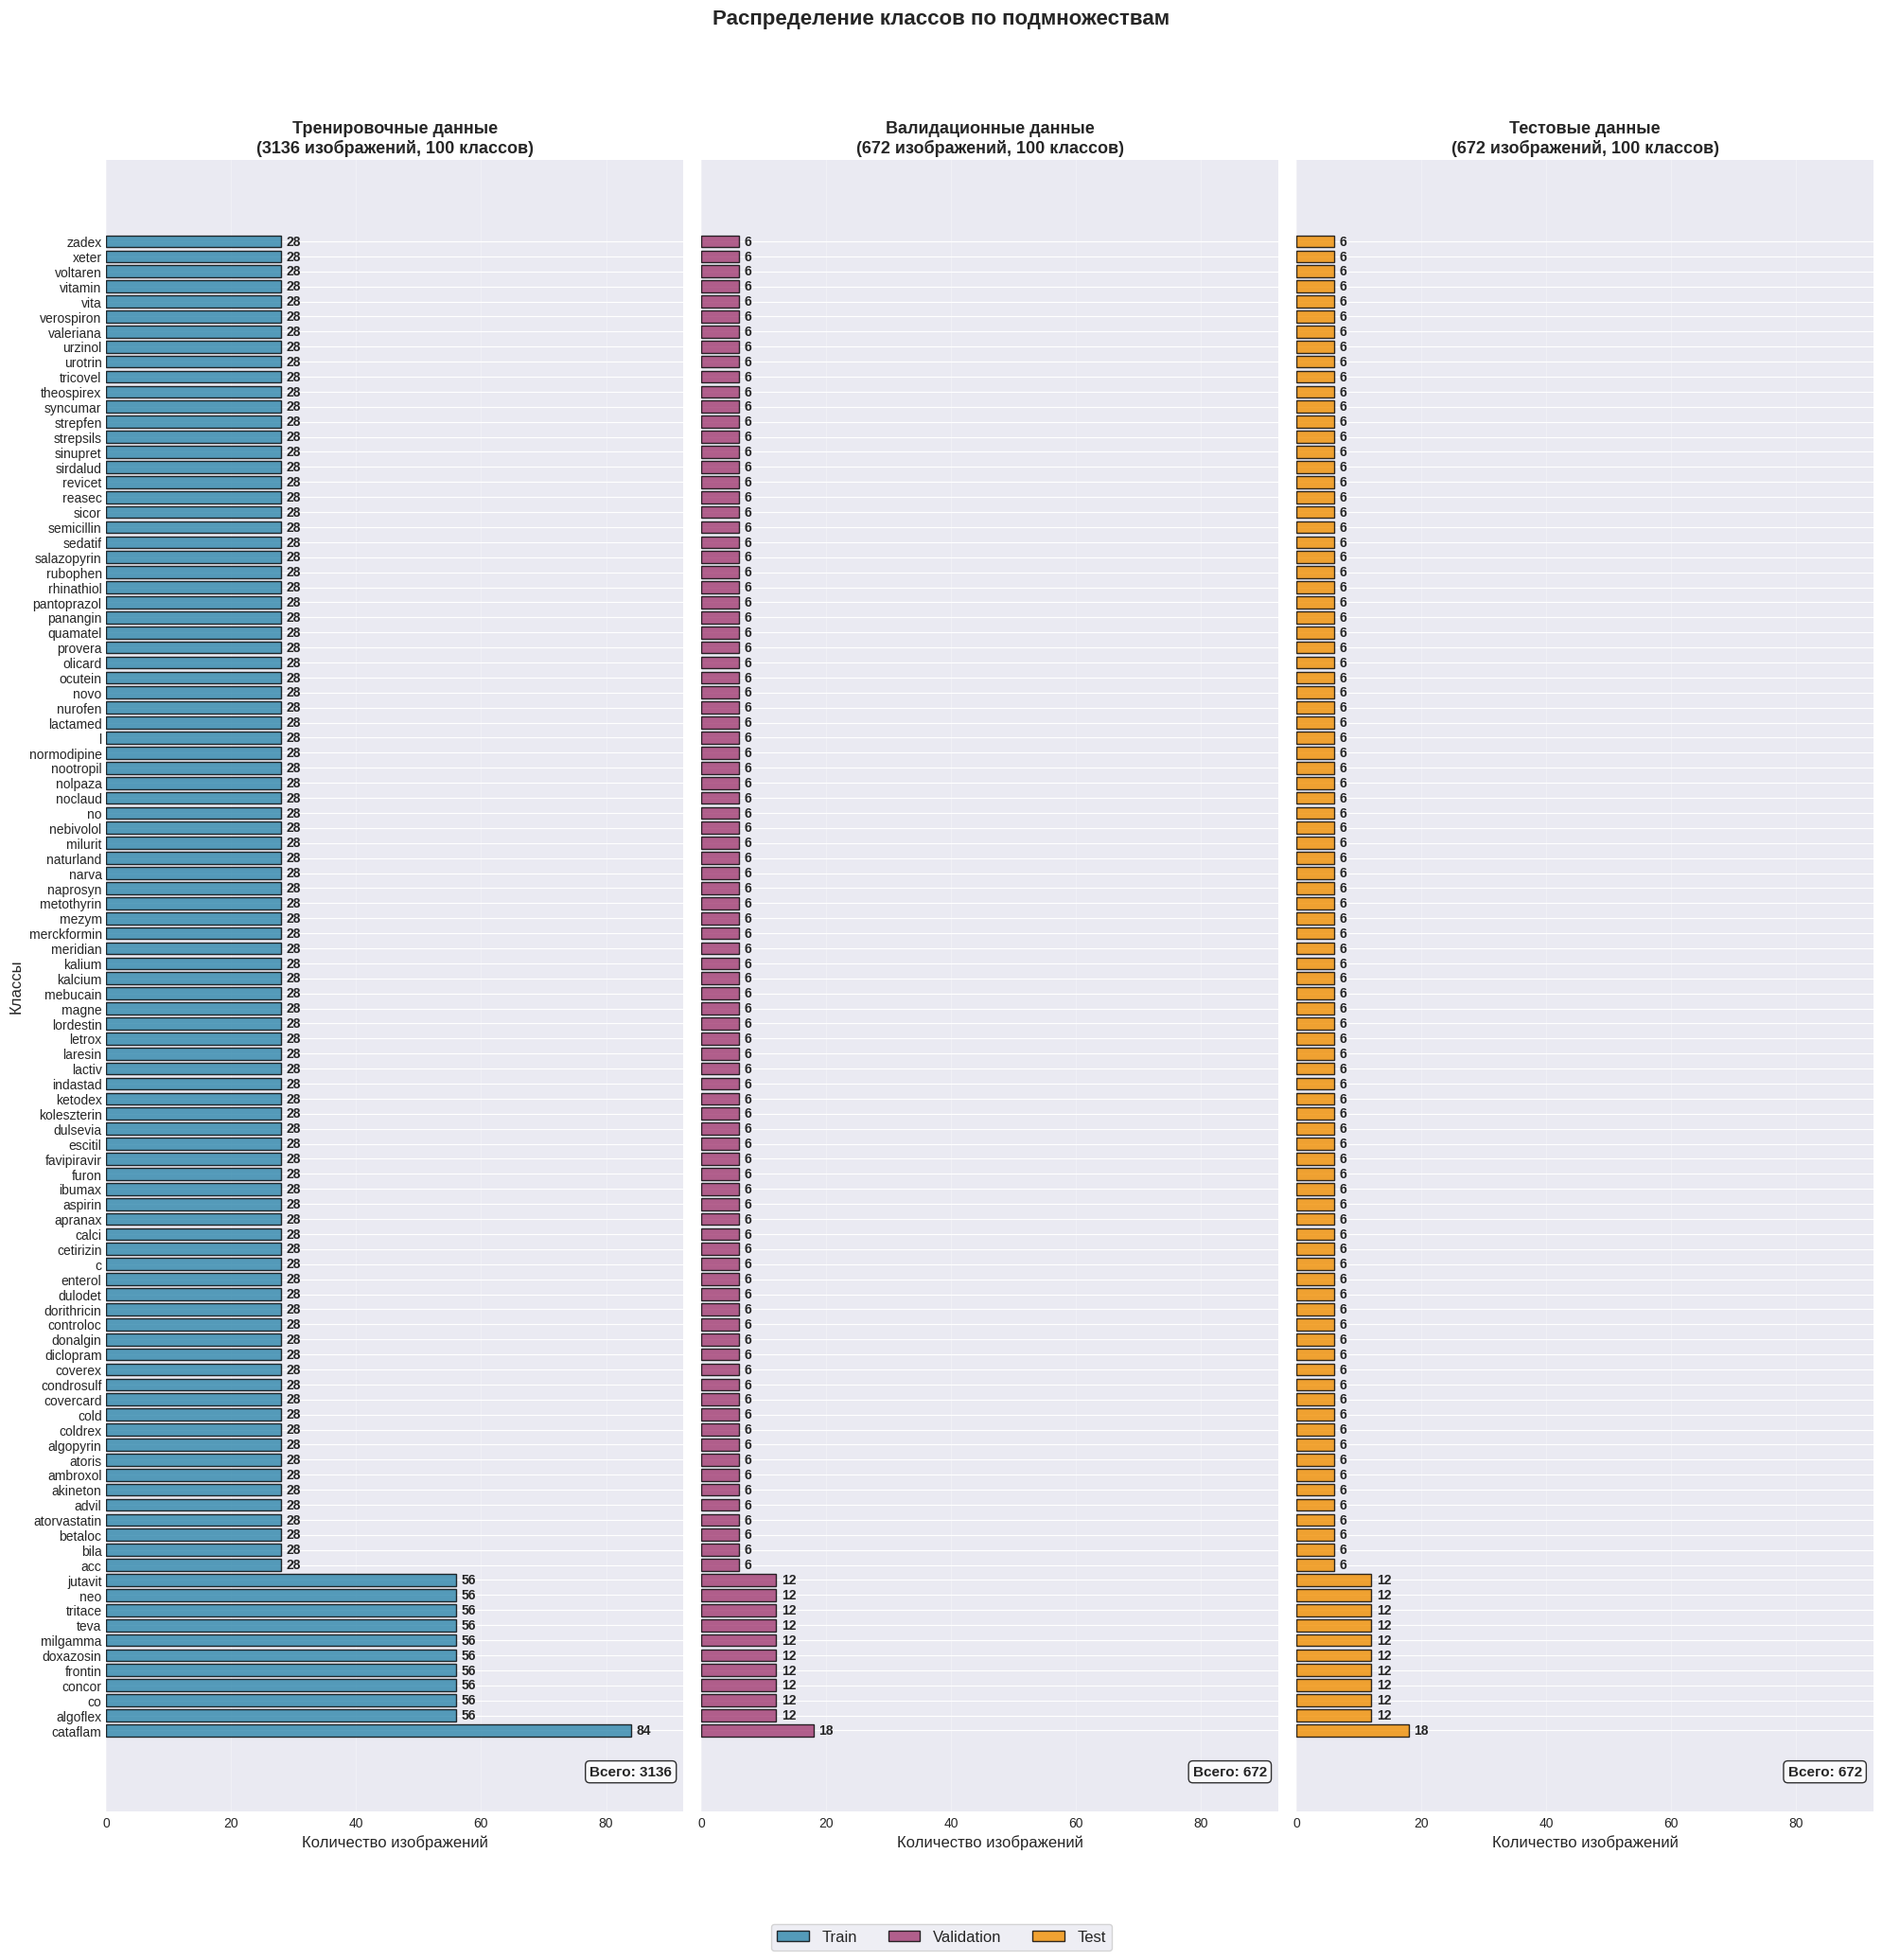

СТАТИСТИКА РАСПРЕДЕЛЕНИЯ КЛАССОВ
Всего уникальных классов: 100
Тренировочные данные: 3136 изображений, 100 классов
Валидационные данные: 672 изображений, 100 классов
Тестовые данные: 672 изображений, 100 классов
Общее количество изображений: 4480

Анализ покрытия классов:
  В Train представлены все классы
  В Validation представлены все классы
  В Test представлены все классы


,class,train,val,test,total
14,cataflam,84,18,18,120
3,algoflex,56,12,12,80
16,co,56,12,12,80
19,concor,56,12,12,80
33,frontin,56,12,12,80
...,...,...,...,...,...
95,vita,28,6,6,40
96,vitamin,28,6,6,40
97,voltaren,28,6,6,40
98,xeter,28,6,6,40


In [18]:
def plot_dataset_distributions(train_dataset, val_dataset, test_dataset, figsize=(20, 20)):
    """
    Строит гистограммы распределения классов для всех трех датасетов на одном графике

    Args:
        train_dataset: Объект тренировочного датасета
        val_dataset: Объект валидационного датасета
        test_dataset: Объект тестового датасета
        figsize: Размер фигуры
    """

    import matplotlib.pyplot as plt
    import numpy as np

    # Получаем распределение классов для каждого датасета
    train_dist = train_dataset.get_class_distribution()
    val_dist = val_dataset.get_class_distribution()
    test_dist = test_dataset.get_class_distribution()

    # Собираем все уникальные классы
    all_classes = set(train_dist.keys()) | set(val_dist.keys()) | set(test_dist.keys())
    all_classes_sorted = sorted(list(all_classes))

    # Создаем DataFrame для удобства
    data = {
        'class': all_classes_sorted,
        'train': [train_dist.get(cls, 0) for cls in all_classes_sorted],
        'val': [val_dist.get(cls, 0) for cls in all_classes_sorted],
        'test': [test_dist.get(cls, 0) for cls in all_classes_sorted],
        'total': [train_dist.get(cls, 0) + val_dist.get(cls, 0) + test_dist.get(cls, 0)
                  for cls in all_classes_sorted]
    }

    df = pd.DataFrame(data)
    df = df.sort_values('total', ascending=False)

    # Настройка стиля
    plt.style.use('seaborn-v0_8-darkgrid')

    # Создаем фигуру с тремя subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    fig.suptitle('Распределение классов по подмножествам', fontsize=16, fontweight='bold')

    # Цвета для разных датасетов
    colors = ['#2E86AB', '#A23B72', '#F18F01']

    # Подготовка данных для графиков
    subsets = ['train', 'val', 'test']
    titles = ['Тренировочные данные', 'Валидационные данные', 'Тестовые данные']
    datasets = [train_dataset, val_dataset, test_dataset]

    # Максимальное значение для установки лимита оси Y
    max_count = max(df['train'].max(), df['val'].max(), df['test'].max())

    for idx, (ax, subset, title, dataset) in enumerate(zip(axes, subsets, titles, datasets)):
        # Получаем данные для текущего подмножества
        subset_data = df[['class', subset]].copy()
        subset_data = subset_data[subset_data[subset] > 0]  # Только классы с ненулевым количеством
        subset_data = subset_data.sort_values(subset, ascending=False)

        # Создаем гистограмму
        bars = ax.barh(subset_data['class'], subset_data[subset],
                      color=colors[idx], alpha=0.8, edgecolor='black')

        # Настройки графика
        ax.set_xlabel('Количество изображений', fontsize=12)
        ax.set_title(f'{title}\n({len(dataset)} изображений, {len(subset_data)} классов)',
                    fontsize=13, fontweight='bold')

        # Добавляем значения на столбцы
        for bar in bars:
            width = bar.get_width()
            ax.text(width + max_count * 0.01, bar.get_y() + bar.get_height()/2,
                   f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

        # Настройка сетки
        ax.grid(True, alpha=0.3, axis='x')
        ax.set_xlim(0, max_count * 1.1)  # Добавляем 10% запаса

        # Добавляем метку общего количества
        ax.text(0.98, 0.02, f'Всего: {df[subset].sum()}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Общие настройки
    axes[0].set_ylabel('Классы', fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Место для заголовка

    # Добавляем легенду под графиками
    fig.legend(['Train', 'Validation', 'Test'],
               loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.05),
               fontsize=12, frameon=True)

    plt.show()

    # Выводим статистику
    print("="*80)
    print("СТАТИСТИКА РАСПРЕДЕЛЕНИЯ КЛАССОВ")
    print("="*80)
    print(f"Всего уникальных классов: {len(all_classes_sorted)}")
    print(f"Тренировочные данные: {len(train_dataset)} изображений, {len(train_dist)} классов")
    print(f"Валидационные данные: {len(val_dataset)} изображений, {len(val_dist)} классов")
    print(f"Тестовые данные: {len(test_dataset)} изображений, {len(test_dist)} классов")
    print(f"Общее количество изображений: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

    # Проверяем, есть ли классы, которые отсутствуют в каком-то подмножестве

    print("\nАнализ покрытия классов:")
    for subset_name, subset_dist in [('Train', train_dist), ('Validation', val_dist), ('Test', test_dist)]:
        missing_classes = set(all_classes_sorted) - set(subset_dist.keys())
        if missing_classes:
            print(f"  В {subset_name} отсутствуют классы: {sorted(missing_classes)}")
        else:
            print(f"  В {subset_name} представлены все классы")

    return df

plot_dataset_distributions(train_dataset, val_dataset, test_dataset)

In [5]:
# Создаем DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 3. Create models and train it

In [20]:
# Определяем устройство
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Используемое устройство: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Создаем модель
print("\n" + "="*60)
print("Создание модели...")
model = OGYEI_Classifier(
    num_classes = 100,
    model_name = "rexnet_150",
    pretrained = True,
    dropout_rate = 0.3,
    unfreeze_layers = 2
)

print(model)

# Считаем параметры
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,} ({trainable_params/total_params:.1%})")



Используемое устройство: cuda
GPU: Tesla T4
Память GPU: 15.83 GB

Создание модели...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Размораживание 2 слоев с конца:
  Всего слоев: 17
  Разморожены слои: 15-16
Параметры: 2,836,636 обучаемых из 8,842,445 (32.1%)
Модель создана: rexnet_150
Количество классов: 100
Размерность features: 1920
Количество размороженных слоев: 2
OGYEI_Classifier(
  (model): RexNet(
    (stem): ConvNormAct(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
    )
    (features): Sequential(
      (0): LinearBottleneck(
        (conv_dw): ConvNormAct(
          (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn): BatchNormAct2d(
            48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Identity()
          )
        )
        (act_dw): ReLU6()
        (conv


Начало обучения...
Начинаем обучение на cuda...
Размер тренировочного набора: 3136
Размер валидационного набора: 672


Epoch 1/30 [Val]: 100%|██████████| 6/6 [00:56<00:00,  9.42s/it, loss=4.04, acc=9.38]


✓ Модель сохранена! Val Acc: 8.04%

Epoch 1/30:
  Train Loss: 4.4269, Train Acc: 4.85%
  Val Loss: 4.1136, Val Acc: 8.04%
  Learning Rate: 0.000997
  Best Val Acc: 8.04%
  Epochs no improve: 0/10


Epoch 2/30 [Val]: 100%|██████████| 6/6 [00:48<00:00,  8.02s/it, loss=3, acc=21.9]


✓ Модель сохранена! Val Acc: 41.67%

Epoch 2/30:
  Train Loss: 3.4542, Train Acc: 23.28%
  Val Loss: 2.7763, Val Acc: 41.67%
  Learning Rate: 0.000989
  Best Val Acc: 41.67%
  Epochs no improve: 0/10


...

✓ Модель сохранена! Val Acc: 93.01%

Epoch 28/30:
  Train Loss: 1.0672, Train Acc: 95.79%
  Val Loss: 1.0904, Val Acc: 93.01%
  Learning Rate: 0.000011
  Best Val Acc: 93.01%
  Epochs no improve: 0/10


Epoch 29/30 [Val]: 100%|██████████| 6/6 [00:48<00:00,  8.08s/it, loss=1.18, acc=87.5]



Epoch 29/30:
  Train Loss: 1.0806, Train Acc: 94.64%
  Val Loss: 1.0953, Val Acc: 92.71%
  Learning Rate: 0.000003
  Best Val Acc: 93.01%
  Epochs no improve: 1/10


Epoch 30/30 [Val]: 100%|██████████| 6/6 [00:48<00:00,  8.04s/it, loss=1.18, acc=93.8]



Epoch 30/30:
  Train Loss: 1.0872, Train Acc: 94.67%
  Val Loss: 1.0947, Val Acc: 93.01%
  Learning Rate: 0.000000
  Best Val Acc: 93.01%
  Epochs no improve: 2/10

Обучение завершено!
Лучшая точность на валидации: 93.01%

Визуализация истории обучения...


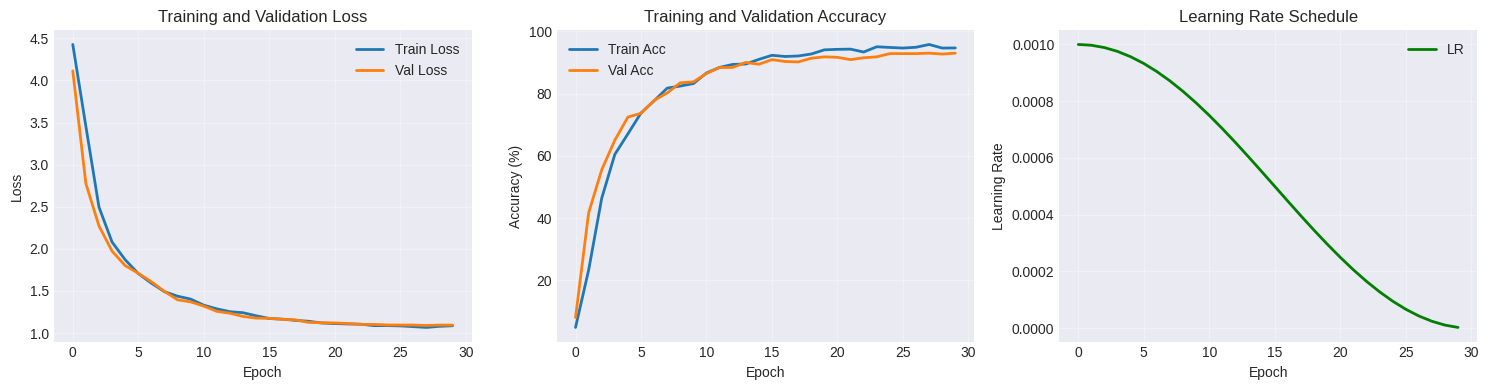


Оценка на тестовом наборе...


Evaluation: 100%|██████████| 6/6 [00:56<00:00,  9.35s/it, acc=90.6]



Тестирование завершено:
  Test Loss: 0.3467
  Test Accuracy: 94.05%
  Correct/Total: 632/672


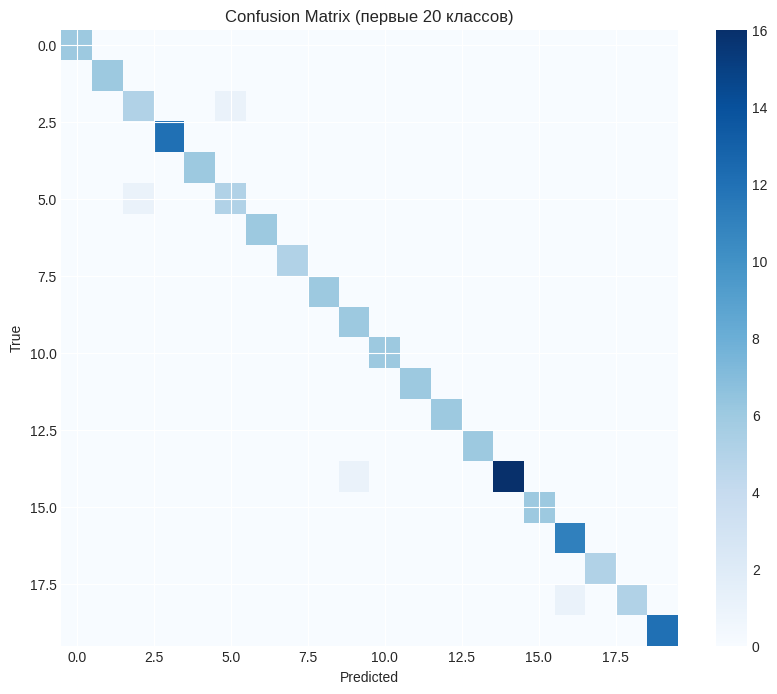


Пример предсказания...
Предсказанный класс: 28
Вероятность: 0.4174
Топ-3 класса: [28, 69, 71]
Топ-3 вероятности: [0.4173588752746582, 0.06274761259555817, 0.062225840985774994]


In [21]:
# Обучаем модель
print("\n" + "="*60)
print("Начало обучения...")

model, history = train_and_validate_model(
    model=model,
    checkpoint_path = 'meds_classifier.pt',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=30,
    learning_rate=1e-3,
    device=device
)

# Пример предсказания на одном изображении
print("\n" + "="*60)
print("Пример предсказания...")

# Берем один батч
images, labels = next(iter(test_loader))
single_image = images[0:1]  # Берем одно изображение

# Получаем предсказание
model.eval()
with torch.no_grad():
    logits = model(single_image.to(next(model.parameters()).device))
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

print(f"Предсказанный класс: {predicted_class}")
print(f"Вероятность: {probs[0, predicted_class]:.4f}")
print(f"Топ-3 класса: {torch.topk(probs[0], 3).indices.tolist()}")
print(f"Топ-3 вероятности: {torch.topk(probs[0], 3).values.tolist()}")


# 4. Inference analysis

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from collections import Counter
import torch
from tqdm import tqdm

def analyze_model_performance(model, test_loader, class_names=None, device='cuda'):
    """
    Полный анализ производительности модели
    """
    
    model.eval()
    model.to(device)
    
    # Сбор предсказаний
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Предсказание'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Если нет названий классов, создаем числовые
    if class_names is None:
        class_names = [f'Class_{i}' for i in range(len(np.unique(all_labels)))]
    
    # 1. Общие метрики
    print("="*60)
    print("ОБЩИЕ МЕТРИКИ МОДЕЛИ")
    print("="*60)
    
    # Classification report
    report = classification_report(all_labels, all_preds, 
                                  target_names=class_names, 
                                  zero_division=0)
    print(report)
    
    # 2. Метрики по классам
    print("\n" + "="*60)
    print("МЕТРИКИ ПО КЛАССАМ")
    print("="*60)
    
    # Вычисляем метрики для каждого класса
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )
    
    # Accuracy по классам
    class_acc = []
    for class_idx in range(len(class_names)):
        mask = all_labels == class_idx
        if mask.sum() > 0:
            acc = (all_preds[mask] == class_idx).mean()
        else:
            acc = 0
        class_acc.append(acc)
    
    # Создаем DataFrame
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Accuracy': class_acc,
        'Support': support
    })
    
    print(metrics_df.round(3).to_string())
    
    # 3. Анализ ошибок
    print("\n" + "="*60)
    print("АНАЛИЗ ОШИБОК")
    print("="*60)
    
    # Находим классы с наибольшим количеством ошибок
    errors_by_class = {}
    for true_class in range(len(class_names)):
        mask = all_labels == true_class
        if mask.sum() > 0:
            errors = (all_preds[mask] != true_class).sum()
            error_rate = errors / mask.sum()
            errors_by_class[true_class] = {
                'errors': errors,
                'error_rate': error_rate,
                'class_name': class_names[true_class]
            }
    
    # 5 классов с наибольшим количеством ошибок
    top_5_errors = sorted(errors_by_class.items(), 
                         key=lambda x: x[1]['errors'], 
                         reverse=True)[:5]
    
    print("ТОП-5 КЛАССОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ ОШИБОК:")
    for class_idx, info in top_5_errors:
        print(f"  {info['class_name']}: {info['errors']} ошибок ({info['error_rate']:.1%})")
    
    # Классы без ошибок
    perfect_classes = []
    for class_idx in range(len(class_names)):
        mask = all_labels == class_idx
        if mask.sum() > 0 and (all_preds[mask] == class_idx).all():
            perfect_classes.append(class_names[class_idx])
    
    print(f"\nКЛАССЫ БЕЗ ОШИБОК ({len(perfect_classes)}):")
    if perfect_classes:
        print("  " + ", ".join(perfect_classes[:10]))
        if len(perfect_classes) > 10:
            print(f"  ... и еще {len(perfect_classes) - 10} классов")
    else:
        print("  Нет классов без ошибок")
    
    # 4. Confusion Matrix анализ
    print("\n" + "="*60)
    print("АНАЛИЗ CONFUSION MATRIX")
    print("="*60)
    
    cm = confusion_matrix(all_labels, all_preds)
    
    # Наиболее частые типы ошибок
    error_pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                error_pairs.append((i, j, cm[i, j]))
    
    # Сортируем по частоте ошибок
    error_pairs.sort(key=lambda x: x[2], reverse=True)
    
    print("НАИБОЛЕЕ ЧАСТЫЕ ПУТАНИЦЫ:")
    for i, j, count in error_pairs[:10]:
        print(f"  {class_names[i]} → {class_names[j]}: {count} ошибок")
    
    # 5. Визуализация
    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*60)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # График 1: Точность по классам
    axes[0, 0].bar(range(len(class_names)), metrics_df['Accuracy'].values)
    axes[0, 0].set_xlabel('Классы')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title('Точность по классам')
    axes[0, 0].set_xticks(range(len(class_names)))
    axes[0, 0].set_xticklabels(class_names, rotation=90, fontsize=8)
    axes[0, 0].axhline(y=metrics_df['Accuracy'].mean(), color='r', linestyle='--', 
                      label=f'Среднее: {metrics_df["Accuracy"].mean():.2f}')
    axes[0, 0].legend()
    
    # График 2: F1-score по классам
    axes[0, 1].bar(range(len(class_names)), metrics_df['F1'].values)
    axes[0, 1].set_xlabel('Классы')
    axes[0, 1].set_ylabel('F1-score')
    axes[0, 1].set_title('F1-score по классам')
    axes[0, 1].set_xticks(range(len(class_names)))
    axes[0, 1].set_xticklabels(class_names, rotation=90, fontsize=8)
    axes[0, 1].axhline(y=metrics_df['F1'].mean(), color='r', linestyle='--',
                      label=f'Среднее: {metrics_df["F1"].mean():.2f}')
    axes[0, 1].legend()
    
    # График 3: Confusion Matrix (топ-20 классов для читаемости)
    num_to_show = min(20, len(class_names))
    cm_small = cm[:num_to_show, :num_to_show]
    class_names_small = class_names[:num_to_show]
    
    sns.heatmap(cm_small, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_small,
                yticklabels=class_names_small,
                ax=axes[1, 0])
    axes[1, 0].set_title(f'Confusion Matrix (первые {num_to_show} классов)')
    axes[1, 0].set_xlabel('Предсказанные')
    axes[1, 0].set_ylabel('Истинные')
    
    # График 4: Распределение ошибок
    error_counts = [info['errors'] for _, info in errors_by_class.items()]
    class_labels = [info['class_name'] for _, info in errors_by_class.items()]
    
    # Берем топ-15 классов по ошибкам
    idx_sorted = np.argsort(error_counts)[-15:][::-1]
    
    axes[1, 1].bar(range(len(idx_sorted)), 
                  [error_counts[i] for i in idx_sorted])
    axes[1, 1].set_xlabel('Классы')
    axes[1, 1].set_ylabel('Количество ошибок')
    axes[1, 1].set_title('Топ-15 классов по количеству ошибок')
    axes[1, 1].set_xticks(range(len(idx_sorted)))
    axes[1, 1].set_xticklabels([class_labels[i] for i in idx_sorted], 
                              rotation=45, fontsize=9)
    
    plt.tight_layout()
    plt.savefig('model_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 6. Ответы на вопросы
    print("\n" + "="*60)
    print("АНАЛИЗ И РЕКОМЕНДАЦИИ")
    print("="*60)
    
    print("\n1. НА КАКИХ 5 КЛАССАХ МОДЕЛЬ ОШИБАЕТСЯ ЧАЩЕ ВСЕГО?")
    for class_idx, info in top_5_errors:
        print(f"   • {info['class_name']}: {info['errors']} ошибок ({info['error_rate']:.1%})")
    
    
    
    print("\n2. НА КАКИХ КЛАССАХ МОДЕЛЬ НЕ СОВЕРШАЕТ ОШИБОК?")
    if perfect_classes:
        print(f"   • {len(perfect_classes)} классов без ошибок")
        print(f"   Примеры: {', '.join(perfect_classes[:5])}")
    else:
        print("   • Нет классов без ошибок")
    
    
    
    # 3. Дополнительные статистики
    print("\n" + "="*60)
    print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
    print("="*60)
    
    # Средняя уверенность предсказаний
    print(f"\nОбщая точность модели: {accuracy_score(all_labels, all_preds):.2%}")
    print(f"Средний F1-score: {metrics_df['F1'].mean():.2%}")
    
    # Количество классов с accuracy < 0.5
    low_acc_classes = metrics_df[metrics_df['Accuracy'] < 0.5]
    print(f"Классов с accuracy < 50%: {len(low_acc_classes)}")
    
    # Количество классов с accuracy > 0.9
    high_acc_classes = metrics_df[metrics_df['Accuracy'] > 0.9]
    print(f"Классов с accuracy > 90%: {len(high_acc_classes)}")
    
    return metrics_df, cm

Размораживание 3 слоев с конца:
  Всего слоев: 17
  Разморожены слои: 14-16
Параметры: 3,944,141 обучаемых из 8,842,445 (44.6%)
Модель создана: rexnet_150
Количество классов: 100
Размерность features: 1920
Количество размороженных слоев: 3


Предсказание:   0%|          | 0/6 [00:00<?, ?it/s]/Users/borisfox/Documents/ML/nn/sprint3/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Предсказание: 100%|██████████| 6/6 [00:55<00:00,  9.20s/it]


ОБЩИЕ МЕТРИКИ МОДЕЛИ
              precision    recall  f1-score   support

         acc       1.00      1.00      1.00         6
       advil       1.00      1.00      1.00         6
    akineton       0.83      0.83      0.83         6
    algoflex       1.00      1.00      1.00        12
   algopyrin       1.00      1.00      1.00         6
    ambroxol       0.83      0.83      0.83         6
     apranax       1.00      1.00      1.00         6
     aspirin       1.00      0.83      0.91         6
      atoris       1.00      1.00      1.00         6
atorvastatin       0.86      1.00      0.92         6
     betaloc       1.00      1.00      1.00         6
        bila       0.86      1.00      0.92         6
           c       1.00      1.00      1.00         6
       calci       1.00      1.00      1.00         6
    cataflam       1.00      0.89      0.94        18
   cetirizin       1.00      1.00      1.00         6
          co       0.92      0.92      0.92        12
      

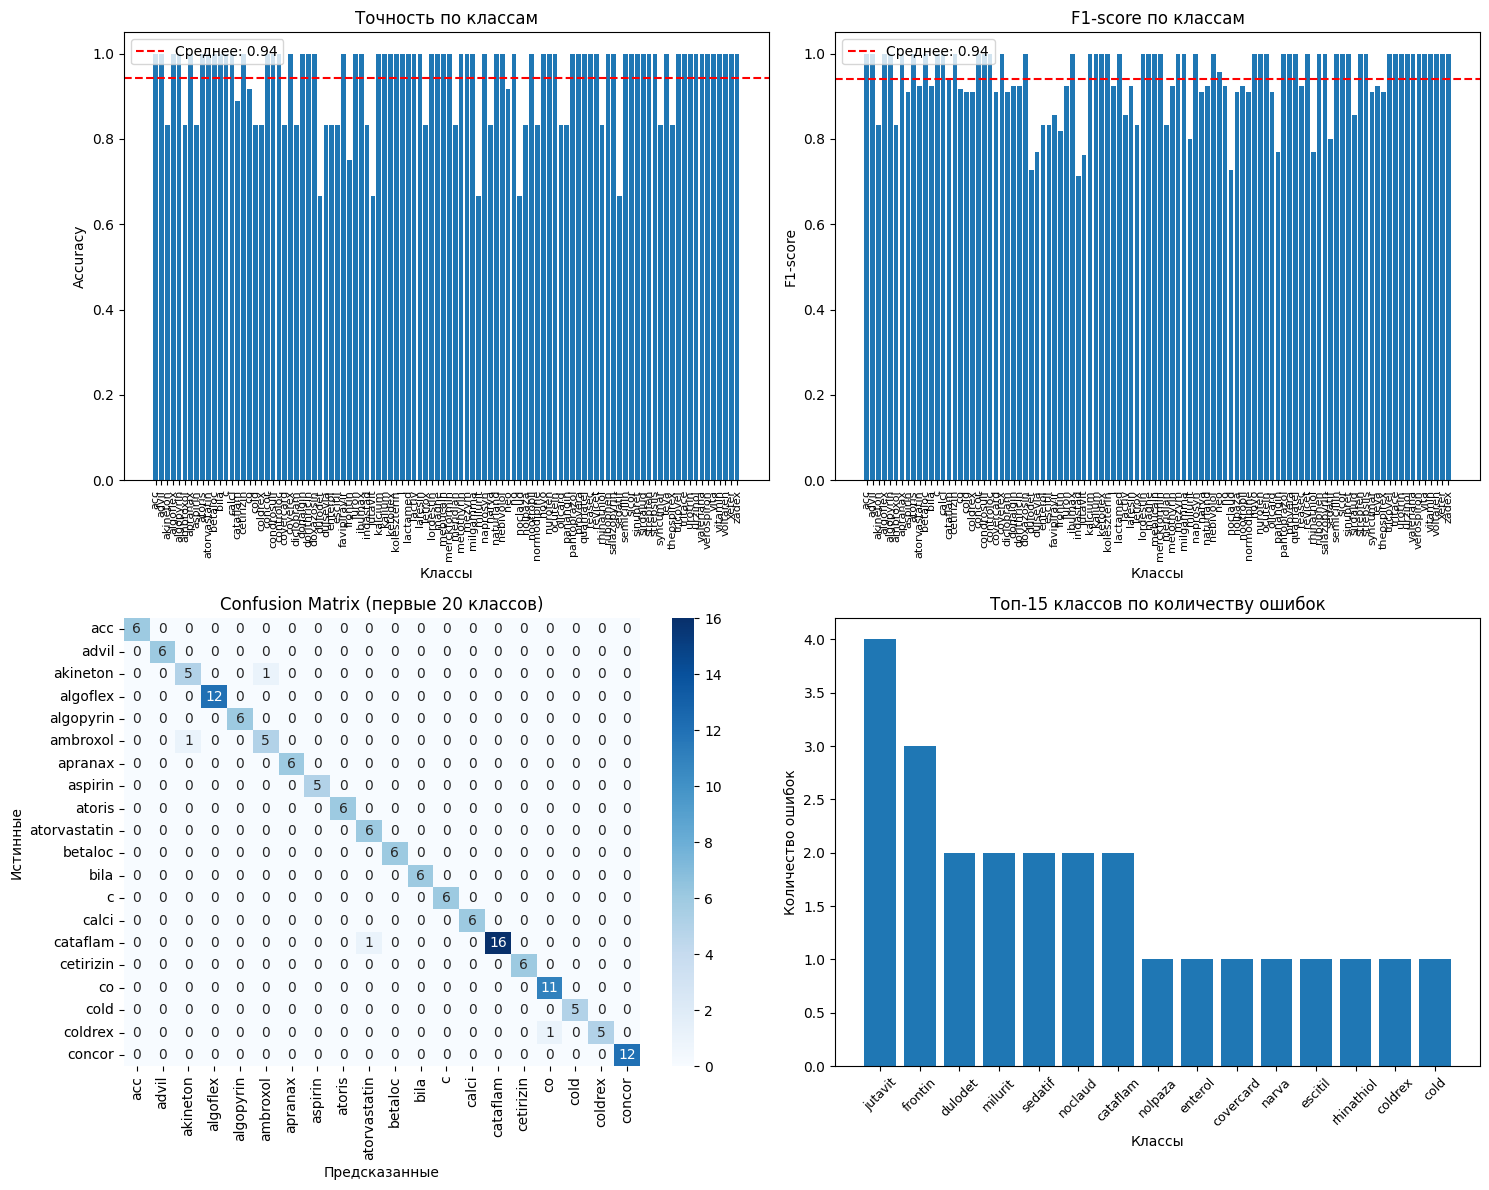


АНАЛИЗ И РЕКОМЕНДАЦИИ

1. НА КАКИХ 5 КЛАССАХ МОДЕЛЬ ОШИБАЕТСЯ ЧАЩЕ ВСЕГО?
   • jutavit: 4 ошибок (33.3%)
   • frontin: 3 ошибок (25.0%)
   • cataflam: 2 ошибок (11.1%)
   • dulodet: 2 ошибок (33.3%)
   • milurit: 2 ошибок (33.3%)

2. НА КАКИХ КЛАССАХ МОДЕЛЬ НЕ СОВЕРШАЕТ ОШИБОК?
   • 70 классов без ошибок
   Примеры: acc, advil, algoflex, algopyrin, apranax

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА

Общая точность модели: 94.05%
Средний F1-score: 94.04%
Классов с accuracy < 50%: 0
Классов с accuracy > 90%: 72

Метрики сохранены в class_metrics.csv


In [11]:
# Загружаем модель

def load_model(checkpoint_path, device='cpu'):
    """
    Загружает модель из чекпоинта
    """
    # Загружаем чекпоинт
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Создаем новую модель с теми же параметрами
    model = OGYEI_Classifier(
        num_classes=checkpoint.get('num_classes', 100),  # Используйте правильные параметры
        model_name=checkpoint.get('model_name', 'rexnet_150'),
        pretrained=False,  # Не загружаем ImageNet веса, т.к. будем загружать свои
        unfreeze_layers=checkpoint.get('unfreeze_layers', 3)
    )
    
    # Загружаем веса модели
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    elif 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        # Если сохранили саму модель (не словарь)
        model = checkpoint
    
    model.to(device)
    model.eval()
    
    return model

model = load_model('models/meds_classifier.pt', device=device)
model.eval()

# Получаем названия классов из датасета
class_names = test_dataset.classes 

# Запускаем анализ
metrics_df, cm = analyze_model_performance(
    model=model,
    test_loader=test_loader,
    class_names=class_names,
    device='cpu'
)

# Сохраняем результаты в CSV
metrics_df.to_csv('class_metrics.csv', index=False)
print("\nМетрики сохранены в class_metrics.csv")

# 5. Conclusions

## 5.1 ПОЧЕМУ МОДЕЛЬ МОЖЕТ ОШИБАТЬСЯ НА ВЫДЕЛЕННЫХ КЛАССАХ?
    
    • Мало данных для обучения (недостаточный support)
    • Визуальное сходство с другими классами
    • Сложная форма/цвет/текстура объекта
    • Плохое качество изображений
    



## 5.2 ПОЧЕМУ ЛУЧШИЕ КЛАССЫ МОДЕЛЬ РАСПОЗНАЁТ БЕЗОШИБОЧНО?
    
    • Уникальные визуальные признаки
    • Достаточно тренировочных данных
    • Хорошее качество изображений
    • Простая и четкая форма объектов
    
## 5.3 КАК МОЖНО УЛУЧШИТЬ ТОЧНОСТЬ КЛАССИФИКАТОРА?
    
    * Добавить больше данных для проблемных классов
    * Использовать больше аугментации (особенно для слабых классов)
    * Попробовать другие архитектуры моделей (замена efficientnet на rexnet_150 обеспечиала прирост точности на 10%)
    * Разраморозить больше слоев для обучения
    * Настроить веса классов (class_weight)
        
